Fit source-only eCMR with positional termination to Dupertuys2026 and generate eCMR3-style diagnostic figures.


In [1]:
# import jax
# jax.config.update("jax_disable_jit", True)
# jax.config.update("jax_debug_nans", True)

import inspect
import json
import os
import sys
import warnings
from pathlib import Path
from typing import Any, Mapping, Sequence, cast, Type

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.helpers import (
    find_project_root,
    generate_trial_mask,
    import_from_string,
    load_data,
    save_dict_to_hdf5,
    save_figure,
)
from jaxcmr.simulation import simulate_h5_from_h5
from jaxcmr.summarize import summarize_parameters

warnings.filterwarnings("ignore")


Parameter Setup

In [2]:
EPS = 2.220446049250313e-16

# Run configuration
base_run_tag = "learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_positional_term"
experiment_count = 10
max_subjects = 0

# Data parameters
data_tag = "Dupertuys2026"
data_path = "../emcr3/data/Dupertuys2026.h5"
figure_dir = "results/figures/fitting"
figure_str = ""
embedding_path = ""
emotion_feature_path = ""
semantic_distance_matrix_path = "../emcr3/data/sim_matrices/List1/sem_matrix_decimals.csv"
feature_column = 6
concat_features = False
trial_query = "data['list_type'] >= 1"
target_directory = "results/"

# algorithm selection
model_name = "eCMR_source_only_phi"
make_factory_path = "jaxcmr.models.ecmr.make_factory"
component_paths = {
    "mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc",
    "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf",
    "context_create_fn": "jaxcmr.components.context.init",
    "termination_policy_create_fn": "jaxcmr.components.termination.PositionalTermination",
}

sim_alg_path = "jaxcmr.simulation.simulate_study_and_free_recall"
loss_fn_path = "jaxcmr.loss.sequence_likelihood.MemorySearchLikelihoodFnGenerator"
fit_alg_path = "jaxcmr.fitting.EvosaxDE"
parameters = {
    "fixed": {
        "allow_repeated_recalls": False,
        "learn_after_context_update": True,
        "modulate_emotion_by_primacy": True,
        "phi_emot_modulates_temporal": False,
        "modulate_temporal_emotion_by_primacy": False,
        "emotion_recall_drift_rate": 1.0,
    },
    "free": {
        "encoding_drift_rate": [EPS, 1 - EPS],
        "start_drift_rate": [EPS, 1 - EPS],
        "recall_drift_rate": [EPS, 1 - EPS],
        "shared_support": [EPS, 100.0],
        "item_support": [EPS, 100.0],
        "learning_rate": [EPS, 1 - EPS],
        "primacy_scale": [EPS, 100.0],
        "primacy_decay": [EPS, 100.0],
        "choice_sensitivity": [EPS, 100.0],
        "emotion_encoding_drift_rate": [EPS, 1 - EPS],
        "emotion_scale": [EPS, 10.0],
        "stop_probability_scale": [EPS, 5.0],
        "stop_probability_growth": [EPS, 10.0],
    },
}

# Fitting mode
subject_indices = []
pooled = True

# Flow toggles
filter_repeated_recalls = True
redo_fits = False
redo_sims = False
redo_figures = True
# hyperparameters
seed = 0
relative_tolerance = 0.0001
absolute_tolerance = 0.0
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = (0.5, 1.0)
best_of = 1
init = "latinhypercube"
display_iterations = True

# Emotion category features for cat_crp (zero-based rows indexed by pres_itemids - 1)
NEGATIVE_IDS = {2,6,7,11,14,15,19,26,29,32,44,45,51,56,57,58,59,60,64,66,67,68,69,73}
cat_features = np.zeros((73, 1), dtype=np.float32)
for img_id in NEGATIVE_IDS:
    cat_features[img_id - 1, 0] = 1.0

# analysis configuration
# Fixed per diagnostic so model/data figures stay visually comparable.
# Limits were chosen from the focused source-only and broad multiplicative fits,
# then rounded to contact-sheet-style ranges that keep the plotted differences legible.
analysis_ylims = {
    "spc": [0.5, 0.8],
    "cat_spc": [0.4, 0.85],
    "recall_by_list_type_image_type": [0.5, 0.9],
    "pnr": [0.0, 0.5],
    "termination_probability": [0.0, 1.0],
    "cat_crp": [0.0, 1.0],
    "crp": [0.0, 0.4],
    "crp_all_listtypes": [0.0, 0.4],
    "crp_pure_listtypes": [0.0, 0.4],
    "conditional_crp_mixed_source_valence": [0.0, 0.4],
    "target_valence_lag_crp_mixed": [0.0, 0.4],
    "target_valence_lag_crp_mixed_after_neutral": [0.0, 0.4],
    "semantic_dist_crp": [0.05, 0.4],
    "semantic_dist_crp_mixed": [0.05, 0.4],
    "semantic_dist_crp_pure_emotional": [0.05, 0.4],
    "semantic_dist_crp_pure_neutral": [0.05, 0.4],
    "semantic_distrank_by_list_type": [0.5, 0.6],
    "lag_rank_by_list_type": [0.5, 0.7],
}
analysis_yticks = {
    "spc": [0.5, 0.6, 0.7, 0.8],
    "cat_spc": [0.4, 0.5, 0.6, 0.7, 0.8],
    "recall_by_list_type_image_type": [0.5, 0.6, 0.7, 0.8, 0.9],
    "pnr": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "termination_probability": [0.0, 0.25, 0.5, 0.75, 1.0],
    "cat_crp": [0.0, 0.25, 0.5, 0.75, 1.0],
    "crp": [0.0, 0.1, 0.2, 0.3, 0.4],
    "crp_all_listtypes": [0.0, 0.1, 0.2, 0.3, 0.4],
    "crp_pure_listtypes": [0.0, 0.1, 0.2, 0.3, 0.4],
    "conditional_crp_mixed_source_valence": [0.0, 0.1, 0.2, 0.3, 0.4],
    "target_valence_lag_crp_mixed": [0.0, 0.1, 0.2, 0.3, 0.4],
    "target_valence_lag_crp_mixed_after_neutral": [0.0, 0.1, 0.2, 0.3, 0.4],
    "semantic_dist_crp": [0.1, 0.2, 0.3, 0.4],
    "semantic_dist_crp_mixed": [0.1, 0.2, 0.3, 0.4],
    "semantic_dist_crp_pure_emotional": [0.1, 0.2, 0.3, 0.4],
    "semantic_dist_crp_pure_neutral": [0.1, 0.2, 0.3, 0.4],
    "semantic_distrank_by_list_type": [0.5, 0.55, 0.6],
    "lag_rank_by_list_type": [0.5, 0.55, 0.6, 0.65, 0.7],
}

comparison_analysis_configs = [
    {
        "target": "jaxcmr.analyses.spc.plot_spc",
        "ylim": analysis_ylims["spc"],
    },
    {
        "target": "jaxcmr.analyses.crp.plot_crp",
        "ylim": analysis_ylims["crp"],
    },
    {
        "target": "jaxcmr.analyses.pnr.plot_pnr",
        "ylim": analysis_ylims["pnr"],
    },
    {
        "target": "jaxcmr.analyses.termination_probability.plot_termination_probability",
        "ylim": analysis_ylims["termination_probability"],
    },
    {
        "target": "jaxcmr.analyses.distcrp.plot_cat_crp",
        "kwargs": {
            "features": cat_features,
            "feature_label": "Emotion",
        },
        "labels": ["Model", "Data"],
        "ylim": analysis_ylims["cat_crp"],
    },
    {
        "target": "jaxcmr.analyses.distcrp.plot_dist_crp",
        "kwargs": {
            "bin_edges": "percentile",
        },
        "labels": ["Model", "Data"],
        "contrast_name": "Source",
        "figure_suffix": "semantic_dist_crp",
        "ylim": analysis_ylims["semantic_dist_crp"],
    },
    {
        "target": "jaxcmr.analyses.distcrp.plot_dist_crp",
        "kwargs": {
            "bin_edges": "percentile",
            "trial_filter_field": "list_type",
            "trial_filter_values": [1],
        },
        "labels": ["Model", "Data"],
        "contrast_name": "Source",
        "figure_suffix": "semantic_dist_crp_mixed",
        "ylim": analysis_ylims["semantic_dist_crp_mixed"],
    },
    {
        "target": "jaxcmr.analyses.distcrp.plot_dist_crp",
        "kwargs": {
            "bin_edges": "percentile",
            "trial_filter_field": "list_type",
            "trial_filter_values": [2],
        },
        "labels": ["Model", "Data"],
        "contrast_name": "Source",
        "figure_suffix": "semantic_dist_crp_pure_emotional",
        "ylim": analysis_ylims["semantic_dist_crp_pure_emotional"],
    },
    {
        "target": "jaxcmr.analyses.distcrp.plot_dist_crp",
        "kwargs": {
            "bin_edges": "percentile",
            "trial_filter_field": "list_type",
            "trial_filter_values": [3],
        },
        "labels": ["Model", "Data"],
        "contrast_name": "Source",
        "figure_suffix": "semantic_dist_crp_pure_neutral",
        "ylim": analysis_ylims["semantic_dist_crp_pure_neutral"],
    },
]

single_analysis_configs = [
    {
        "target": "jaxcmr.analyses.cat_spc.plot_cat_spc",
        "kwargs": {
            "category_field": "valence",
            "category_values": [-1, 0],
        },
        "labels": ["Negative", "Neutral"],
        "color_cycle": ["#d62728", "#1f77b4"],
        "contrast_name": "Category",
        "ylim": analysis_ylims["cat_spc"],
    },
    {
        "target": "jaxcmr.analyses.cat_recall_rate.plot_cat_recall_rate",
        "kwargs": {
            "category_field": "valence",
            "category_values": [-1, 0],
            "valid_field": "pres_itemnos",
            "category_labels": ["Emotional", "Neutral"],
            "split_field": "list_type",
            "split_values": [1, 2, 3],
        },
        "labels": ["Mixed", "Pure Emotional", "Pure Neutral"],
        "color_cycle": ["#ff4d4d", "#4da3df"],
        "contrast_name": "Image Type",
        "figure_suffix": "recall_by_list_type_image_type",
        "ylim": analysis_ylims["recall_by_list_type_image_type"],
    },
    {
        "target": "jaxcmr.analyses.distrank.plot_distrank",
        "kwargs": {
            "split_field": "list_type",
            "split_values": [1, 2, 3],
        },
        "labels": ["Mixed", "Pure Emotional", "Pure Neutral"],
        "color_cycle": ["#7f7f7f", "#d62728", "#1f77b4"],
        "contrast_name": "List Type",
        "figure_suffix": "semantic_distrank_by_list_type",
        "ylim": analysis_ylims["semantic_distrank_by_list_type"],
    },
    {
        "target": "jaxcmr.analyses.lagrank.plot_lagrank",
        "kwargs": {
            "split_field": "list_type",
            "split_values": [1, 2, 3],
            "size": 1,
        },
        "labels": ["Mixed", "Pure Emotional", "Pure Neutral"],
        "color_cycle": ["#7f7f7f", "#d62728", "#1f77b4"],
        "contrast_name": "List Type",
        "figure_suffix": "lag_rank_by_list_type",
        "ylim": analysis_ylims["lag_rank_by_list_type"],
    },
    {
        "target": "jaxcmr.analyses.crp.plot_crp",
        "kwargs": {
            "split_field": "list_type",
            "split_values": [2, 3],
            "size": 1,
        },
        "labels": ["Pure Emotional", "Pure Neutral"],
        "color_cycle": ["#d62728", "#1f77b4"],
        "contrast_name": "List Type",
        "figure_suffix": "crp_pure_listtypes",
        "ylim": analysis_ylims["crp_pure_listtypes"],
    },
    {
        "target": "jaxcmr.analyses.crp.plot_crp",
        "kwargs": {
            "split_field": "list_type",
            "split_values": [1, 2, 3],
            "size": 1,
        },
        "labels": ["Mixed", "Pure Emotional", "Pure Neutral"],
        "color_cycle": ["#7f7f7f", "#d62728", "#1f77b4"],
        "contrast_name": "List Type",
        "figure_suffix": "crp_all_listtypes",
        "ylim": analysis_ylims["crp_all_listtypes"],
    },
    {
        "target": "jaxcmr.analyses.conditional_crp.plot_crp",
        "kwargs": {
            "source_field": "valence",
            "source_values": [-1, 0],
            "trial_filter_field": "list_type",
            "trial_filter_values": [1],
            "size": 1,
        },
        "labels": ["From Emotional", "From Neutral"],
        "color_cycle": ["#d62728", "#1f77b4"],
        "contrast_name": "Source Item",
        "figure_suffix": "conditional_crp_mixed_source_valence",
        "ylim": analysis_ylims["conditional_crp_mixed_source_valence"],
    },
    {
        "target": "jaxcmr.analyses.conditional_crp.plot_crp",
        "kwargs": {
            "target_field": "valence",
            "target_values": [-1, 0],
            "trial_filter_field": "list_type",
            "trial_filter_values": [1],
            "size": 1,
        },
        "labels": ["To Emotional", "To Neutral"],
        "color_cycle": ["#d62728", "#1f77b4"],
        "contrast_name": "Target Item",
        "figure_suffix": "target_valence_lag_crp_mixed",
        "ylim": analysis_ylims["target_valence_lag_crp_mixed"],
    },
    {
        "target": "jaxcmr.analyses.conditional_crp.plot_crp",
        "kwargs": {
            "source_field": "valence",
            "source_values": [0],
            "target_field": "valence",
            "target_values": [-1, 0],
            "trial_filter_field": "list_type",
            "trial_filter_values": [1],
            "size": 1,
        },
        "labels": ["To Emotional", "To Neutral"],
        "color_cycle": ["#d62728", "#1f77b4"],
        "contrast_name": "Target Item",
        "figure_suffix": "target_valence_lag_crp_mixed_after_neutral",
        "ylim": analysis_ylims["target_valence_lag_crp_mixed_after_neutral"],
    },
]


In [3]:
# derive run tag
from jaxcmr.typing import FittingAlgorithm, LossFnGenerator, TrialSimulator


run_tag = f"{base_run_tag}_best_of_{best_of}"
if max_subjects:
    run_tag += f"_nsubs_{max_subjects}"

# set up rng
rng = random.PRNGKey(seed)

# resolve paths against project root
project_root = Path(find_project_root())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
target_directory = os.path.join(project_root, target_directory)
figure_dir = os.path.join(project_root, figure_dir)

# Use the fit stem as the figure prefix unless this notebook was parameterized otherwise.
if not figure_str:
    figure_str = f"{data_tag}_{model_name}_{run_tag}"

# add subdirectories for each product type: json, figures, h5
product_dirs = {}
for product, subdir in {"fits": "fits", "figures": "figures/fitting", "simulations": "simulations"}.items():
    product_dir = os.path.join(target_directory, subdir)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

# Keep notebook-saved figures stable without relying on tight_layout.
def save_current_figure(figure_dir, figure_str, suffix=None, dpi=300):
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.gcf().subplots_adjust(left=0.18, right=0.96, top=0.88, bottom=0.14)
    plt.savefig(figure_path, dpi=dpi)
    plt.show()


# load data
data = load_data(os.path.join(project_root, data_path), max_subjects)
trial_mask = generate_trial_mask(data, trial_query)

# load feature blocks
semantic_features = None
if embedding_path:
    semantic_features = np.load(project_root / embedding_path).astype(np.float32)

semantic_similarity_matrix = None
semantic_distance_matrix = None
if semantic_distance_matrix_path:
    semantic_similarity_matrix = np.genfromtxt(
        project_root / semantic_distance_matrix_path,
        delimiter=",",
    ).astype(np.float32)
    semantic_distance_matrix = 1.0 - semantic_similarity_matrix

categorical_column = None
if emotion_feature_path:
    emotion_features = np.load(project_root / emotion_feature_path).astype(np.float32)
    categorical_column = emotion_features[:, feature_column : feature_column + 1]

modeling_features = semantic_features
if concat_features:
    modeling_features = np.concatenate([categorical_column, semantic_features], axis=1)  # type: ignore

# import analyses
comparison_analyses = []
for config in comparison_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model", "Data"))))
    contrast_name = config.get("contrast_name", "Source")
    ylim = config.get("ylim", analysis_ylims.get(str(figure_suffix)))
    yticks = config.get("yticks", analysis_yticks.get(str(figure_suffix)))
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if analysis_name in {"plot_dist_crp", "plot_distrank"} and semantic_distance_matrix is not None:
        extra_kwargs.setdefault("distance_matrix", semantic_distance_matrix)
    elif analysis_name in {"plot_dist_crp", "plot_distrank"} and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    comparison_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': ylim,
            'yticks': yticks,
            'color_cycle': config.get('color_cycle', None)
        }
    )


single_analyses = []
for config in single_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model",))))
    contrast_name = config.get("contrast_name", "Source")
    ylim = config.get("ylim", analysis_ylims.get(str(figure_suffix)))
    yticks = config.get("yticks", analysis_yticks.get(str(figure_suffix)))
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if analysis_name in {"plot_dist_crp", "plot_distrank"} and semantic_distance_matrix is not None:
        extra_kwargs.setdefault("distance_matrix", semantic_distance_matrix)
    elif analysis_name in {"plot_dist_crp", "plot_distrank"} and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    single_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': ylim,
            'yticks': yticks,
            'color_cycle': config.get('color_cycle', None)
        }
    )

# configure model factory
make_factory = import_from_string(make_factory_path)
model_factory = make_factory(
    **{key: import_from_string(path) for key, path in component_paths.items()}
)

# import fitting and simulation functions
fitting_algorithm: Type[FittingAlgorithm] = import_from_string(fit_alg_path)
loss_fn_generator: Type[LossFnGenerator] = import_from_string(loss_fn_path)
simulate_trial_fn: TrialSimulator = import_from_string(sim_alg_path)

# derive list of query parameters from keys of `parameters`
query_parameters = list(parameters["free"].keys())

# make sure repeatedrecalls is in either both data_tag or data_path, or is in neither
if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )


Fit model.

In [4]:
from jaxcmr.helpers import make_subject_trial_masks

fit_stem = f"{data_tag}_{model_name}_{run_tag}"
fit_path = Path(product_dirs["fits"]) / f"{fit_stem}.json"
metadata = {
    "run_tag": run_tag,
    "data_tag": data_tag,
    "trial_query": trial_query,
    "model": model_name,
    "name": fit_stem,
    "components": component_paths,
    "fit_algorithm": fit_alg_path,
    "loss_function": loss_fn_path,
    "model_factory": make_factory_path,
    "embedding_path": embedding_path,
    "semantic_distance_matrix_path": semantic_distance_matrix_path,
    "emotion_feature_path": emotion_feature_path,
    "feature_column": str(feature_column),
    "concat_features": str(concat_features),
}

# Determine output path: per-subject partial or full
if subject_indices:
    sub_label = "_".join(str(i) for i in subject_indices)
    fit_path = Path(product_dirs["fits"]) / f"{fit_stem}_sub{sub_label}.json"

if fit_path.exists() and not redo_fits:
    with fit_path.open() as handle:
        results = json.load(handle)
    if "subject" not in results["fits"]:
        results["fits"]["subject"] = results.get("subject", [])
    results |= metadata

else:
    fitter = fitting_algorithm(
        data,
        modeling_features,
        parameters["fixed"],
        model_factory,
        loss_fn_generator,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "absolute_tolerance": absolute_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "progress_bar": True,
            "display_iterations": display_iterations,
            "best_of": best_of,
            "bounds": parameters["free"],
            "seed": seed,
            "init": init,
        },
    )

    if pooled:
        results = fitter.fit(trial_mask)
    elif subject_indices:
        subject_masks, unique_subjects = make_subject_trial_masks(
            trial_mask, data["subject"].flatten()
        )
        combined_mask = jnp.zeros_like(trial_mask, dtype=bool)
        for idx in subject_indices:
            combined_mask = combined_mask | subject_masks[idx]
        if len(subject_indices) == 1:
            results = fitter.fit(combined_mask, subject_id=int(unique_subjects[subject_indices[0]]))
        else:
            results = fitter.fit_subjects(combined_mask)
    else:
        results = fitter.fit_subjects(trial_mask)

    results |= metadata
    with fit_path.open("w") as handle:
        json.dump(results, handle, indent=4)

print(
    summarize_parameters(
        [results],
        query_parameters,
        include_std=not pooled and not subject_indices,
        include_ci=not pooled and not subject_indices,
    )
)


| Parameter | Statistic | Dupertuys2026 eCMR semantic source only phi learn after encoding free recall 1 semantic learn after encoding free recall 1 diffw 0p5 1p0 rtol 1e-4 pooled evosax fixed term best of 1 |
|---|---|---|
| fitness | mean | 7134.61 |
|  | min | 7134.61 |
|  | max | 7134.61 |
| encoding drift rate | mean | 0.69 |
|  | min | 0.69 |
|  | max | 0.69 |
| start drift rate | mean | 0.79 |
|  | min | 0.79 |
|  | max | 0.79 |
| recall drift rate | mean | 0.71 |
|  | min | 0.71 |
|  | max | 0.71 |
| shared support | mean | 45.51 |
|  | min | 45.51 |
|  | max | 45.51 |
| item support | mean | 30.30 |
|  | min | 30.30 |
|  | max | 30.30 |
| learning rate | mean | 0.97 |
|  | min | 0.97 |
|  | max | 0.97 |
| primacy scale | mean | 19.23 |
|  | min | 19.23 |
|  | max | 19.23 |
| primacy decay | mean | 0.00 |
|  | min | 0.00 |
|  | max | 0.00 |
| choice sensitivity | mean | 18.37 |
|  | min | 18.37 |
|  | max | 18.37 |
| semantic scale | mean | 8.14 |
|  | min | 8.14 |
|  | max | 8

Simulate from fitted parameters.

In [5]:
#| code-summary: either load or perform model simulations

sim_path = os.path.join(
    product_dirs["simulations"], f"{data_tag}_{model_name}_{run_tag}.h5"
)
if subject_indices:
    sub_label = "_".join(str(i) for i in subject_indices)
    sim_path = os.path.join(
        product_dirs["simulations"], f"{data_tag}_{model_name}_{run_tag}_sub{sub_label}.h5"
    )
print(sim_path)

rng, rng_iter = random.split(rng)
params = {key: jnp.array(val) for key, val in results["fits"].items()}  # type: ignore

if pooled:
    unique_subjects = jnp.unique(jnp.array(data["subject"]))
    n_subjects = unique_subjects.shape[0]
    params = {
        key: jnp.repeat(val, n_subjects) if key != "subject" else unique_subjects
        for key, val in params.items()
    }

# Use per-subject mask for simulation when subject_indices is set
sim_trial_mask = trial_mask
if subject_indices:
    from jaxcmr.helpers import make_subject_trial_masks as _make_masks
    _subj_masks, _ = _make_masks(trial_mask, data["subject"].flatten())
    sim_trial_mask = jnp.zeros_like(trial_mask, dtype=bool)
    for _idx in subject_indices:
        sim_trial_mask = sim_trial_mask | _subj_masks[_idx]

if os.path.exists(sim_path) and not redo_sims and not redo_fits:
    sim = load_data(sim_path)
    print(f"Loaded from {sim_path}")

else:
    sim = simulate_h5_from_h5(
        model_factory,
        data,
        modeling_features,
        params,
        sim_trial_mask,
        experiment_count,
        rng_iter,
        simulate_trial_fn=simulate_trial_fn,
    )

    save_dict_to_hdf5(sim, sim_path)  # type: ignore
    print(f"Saved to {sim_path}")

if filter_repeated_recalls:
    sim["recalls"] = repetition.filter_repeated_recalls(sim["recalls"])


/Users/jordangunn/workspace/emcr3/results/simulations/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1.h5


Loaded from /Users/jordangunn/workspace/emcr3/results/simulations/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1.h5


Figures

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_cat_spc_data.png)


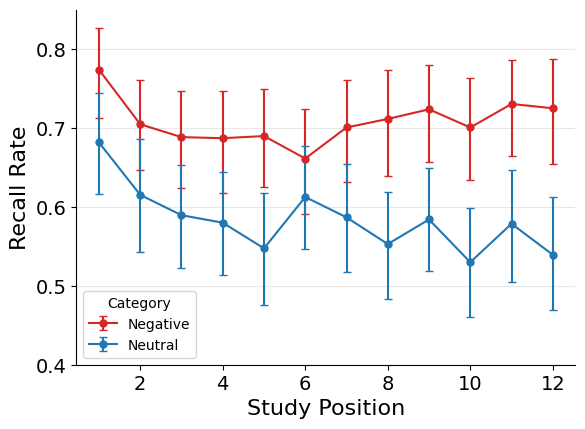

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_cat_spc_sim.png)


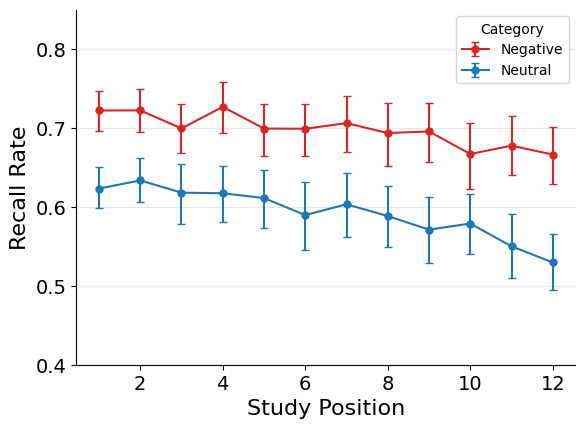

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_recall_by_list_type_image_type_data.png)


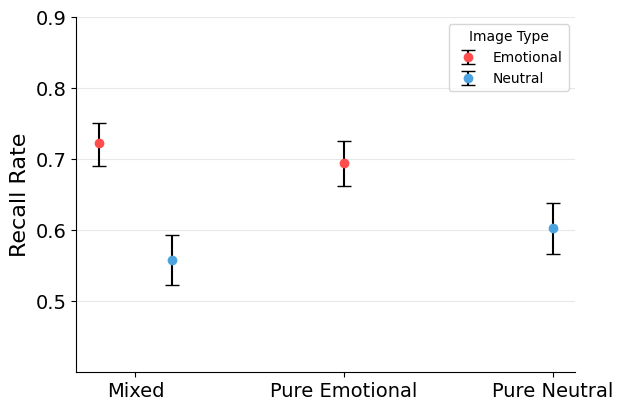

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_recall_by_list_type_image_type_sim.png)


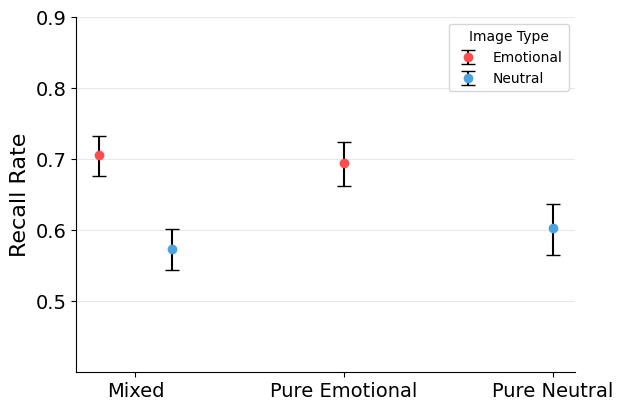

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_semantic_distrank_by_list_type_data.png)


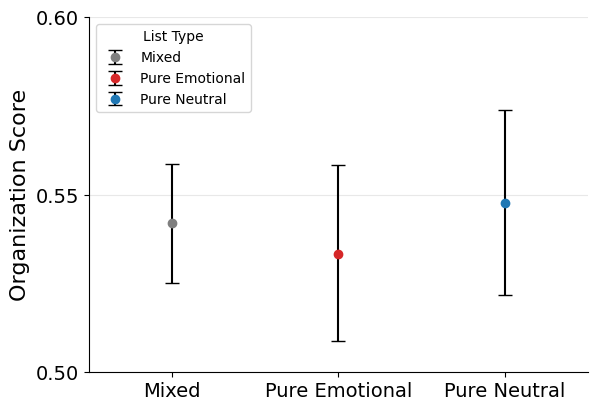

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_semantic_distrank_by_list_type_sim.png)


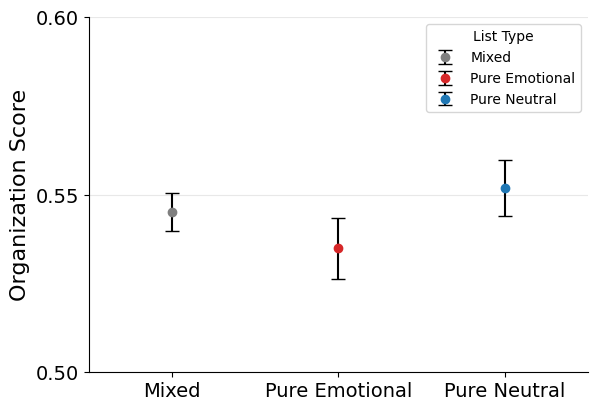

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_lag_rank_by_list_type_data.png)


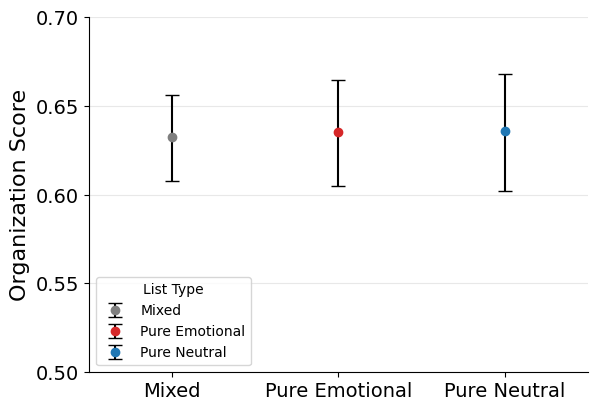

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_lag_rank_by_list_type_sim.png)


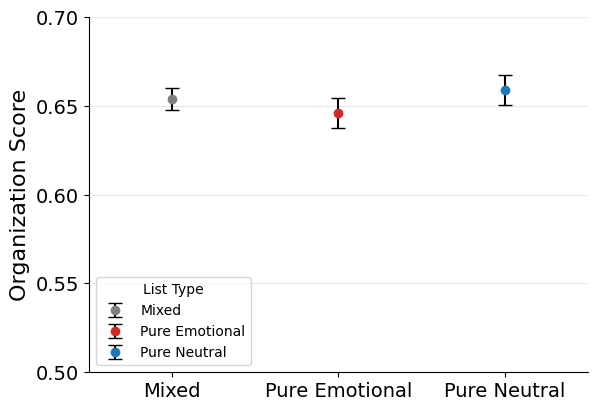

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_crp_pure_listtypes_data.png)


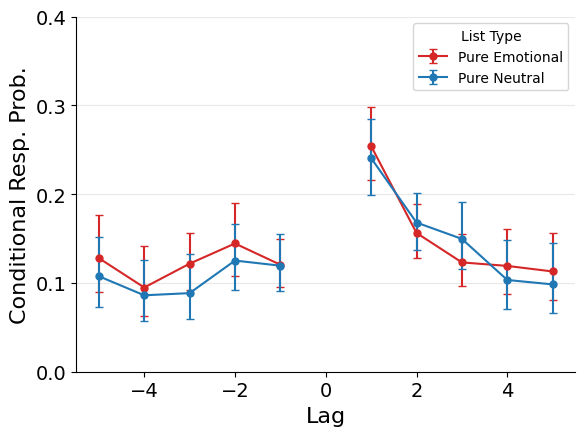

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_crp_pure_listtypes_sim.png)


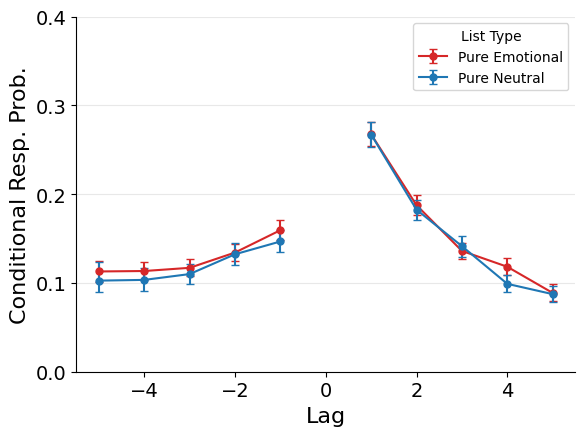

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_crp_all_listtypes_data.png)


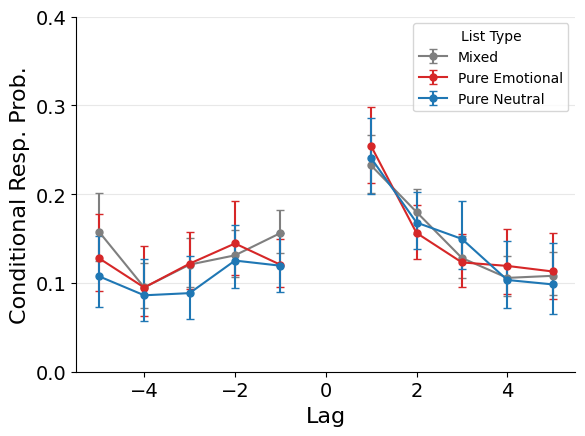

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_crp_all_listtypes_sim.png)


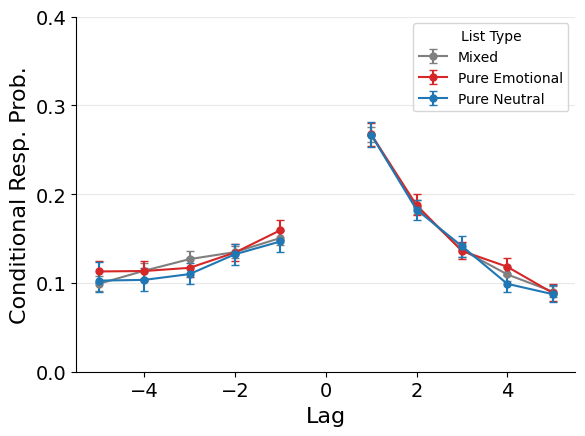

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_conditional_crp_mixed_source_valence_data.png)


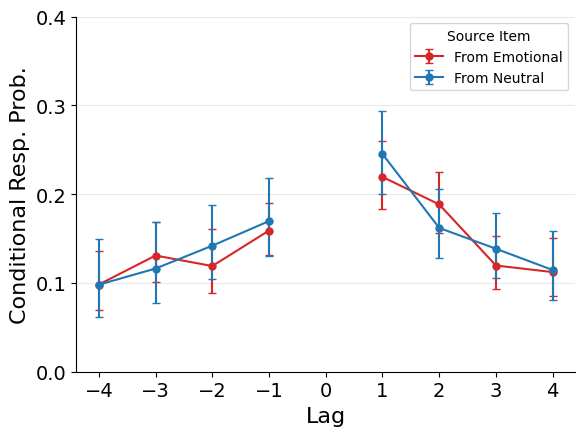

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_conditional_crp_mixed_source_valence_sim.png)


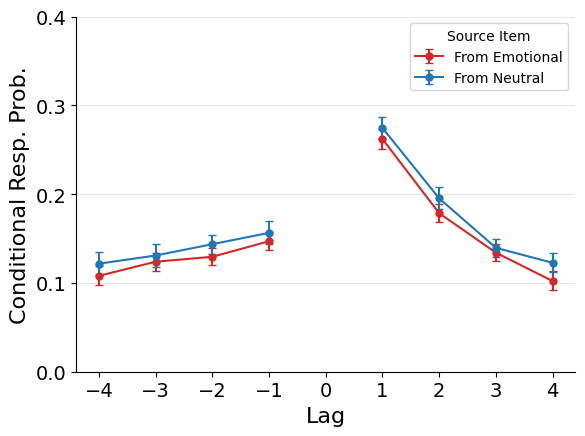

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_target_valence_lag_crp_mixed_data.png)


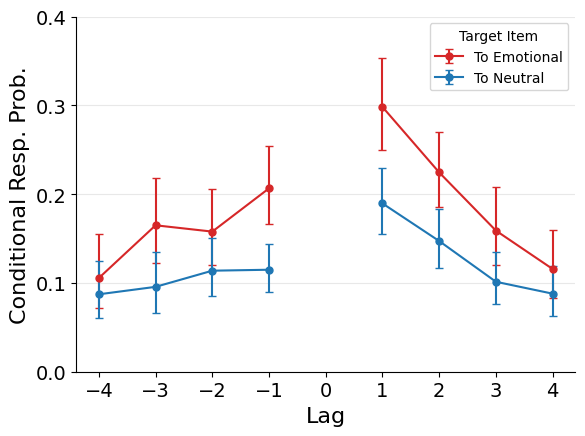

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_target_valence_lag_crp_mixed_sim.png)


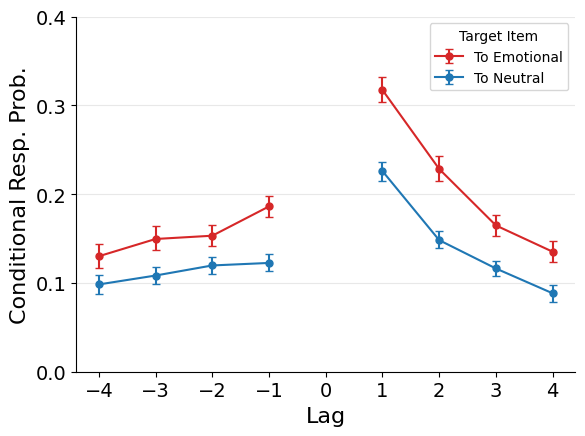

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_target_valence_lag_crp_mixed_after_neutral_data.png)


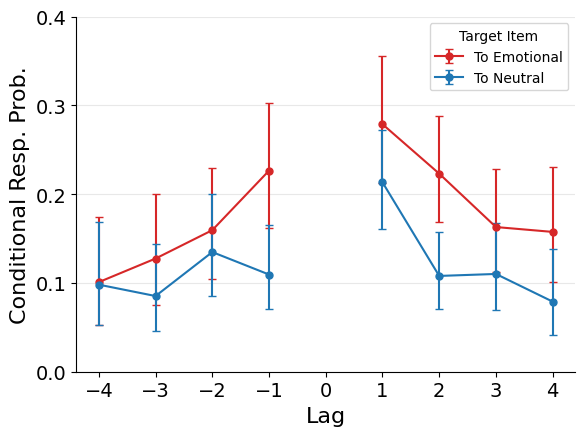

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_target_valence_lag_crp_mixed_after_neutral_sim.png)


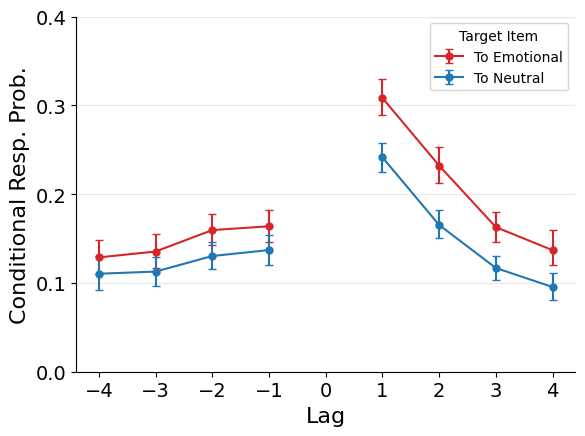

In [6]:
#|code-summary: single-dataset views

for analysis_cfg in single_analyses:
    analysis_fn = analysis_cfg["target"]
    analysis_suffix = analysis_cfg["figure_suffix"]

    trial_mask = generate_trial_mask(data, trial_query)
    sim_trial_mask = generate_trial_mask(sim, trial_query)

    for dataset_label, (dataset, trial_mask) in zip(
        ["data", "sim"], [(data, trial_mask), (sim, sim_trial_mask)]
    ):

        if analysis_cfg.get("color_cycle") is None:
            color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
        else:
            color_cycle = analysis_cfg["color_cycle"].copy()

        base_kwargs = {
            "datasets": dataset,
            "trial_masks": np.array(trial_mask),
            "color_cycle": color_cycle,
            "labels": list(analysis_cfg["labels"]),
            "contrast_name": analysis_cfg["contrast_name"],
            "axis": None,
        }
        base_kwargs |= analysis_cfg["kwargs"]

        # Handle field-based split plots, e.g. pure-list or all-list-type CRP.
        split_field = base_kwargs.pop("split_field", None)
        split_values = base_kwargs.pop("split_values", None)
        if base_kwargs.pop("list_type_split", False):
            split_field = "list_type"
            split_values = [2, 3]

        if split_field is not None:
            if split_values is None:
                raise ValueError("split_values must be provided when split_field is set")
            split_values = list(split_values)
            split_data = dataset[split_field].flatten()
            base_kwargs["datasets"] = [dataset] * len(split_values)
            base_kwargs["trial_masks"] = [
                np.array(trial_mask & (split_data == value))
                for value in split_values
            ]

        # Restrict all plotted contrasts to a subset of trials, e.g. mixed lists only.
        trial_filter_field = base_kwargs.pop("trial_filter_field", None)
        trial_filter_values = base_kwargs.pop("trial_filter_values", None)
        if trial_filter_field is not None:
            if trial_filter_values is None:
                raise ValueError("trial_filter_values must be provided when trial_filter_field is set")
            trial_filter_values = list(trial_filter_values)
            filter_data = np.asarray(dataset[trial_filter_field]).flatten()
            filter_mask = np.isin(filter_data, np.asarray(trial_filter_values))
            current_trial_masks = base_kwargs["trial_masks"]
            if isinstance(current_trial_masks, list):
                base_kwargs["trial_masks"] = [
                    np.array(mask & filter_mask) for mask in current_trial_masks
                ]
            else:
                base_kwargs["trial_masks"] = np.array(current_trial_masks & filter_mask)

        signature = inspect.signature(analysis_fn)
        filtered_kwargs = {
            name: value
            for name, value in base_kwargs.items()
            if name in signature.parameters
        }

        figure_path = (
            os.path.join(
                figure_dir, f"{figure_str}_{analysis_suffix}_{dataset_label}.png"
            )
            if figure_str
            else None
        )
        if figure_path and os.path.exists(figure_path) and not redo_figures:
            display(Image(filename=figure_path))
            continue

        axis = analysis_fn(**filtered_kwargs)

        if analysis_cfg["ylim"] is not None:
            for current_axis in plt.gcf().axes:
                current_axis.set_ylim(analysis_cfg["ylim"])
        if analysis_cfg.get("yticks") is not None:
            for current_axis in plt.gcf().axes:
                current_axis.set_yticks(analysis_cfg["yticks"])

        if figure_path:
            print(f"![]({figure_path})")
        save_current_figure(
            figure_dir,
            figure_str,
            suffix=f"{analysis_suffix}_{dataset_label}",
        )


![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_spc.png)
plot_spc


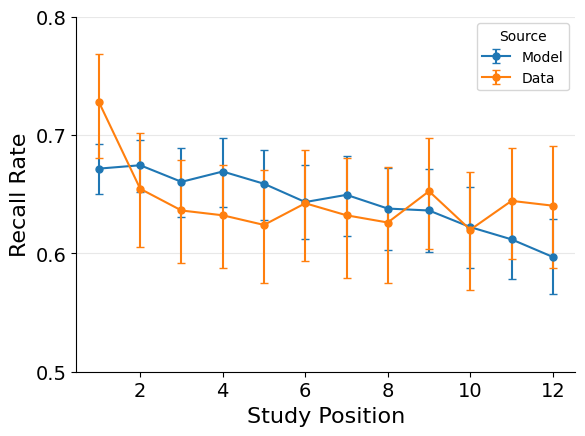

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_crp.png)
plot_crp


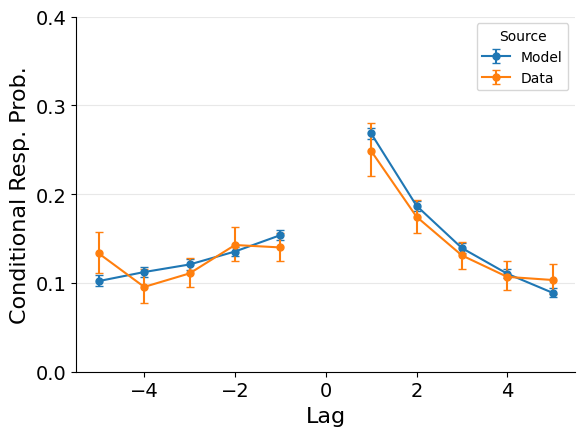

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_pnr.png)
plot_pnr


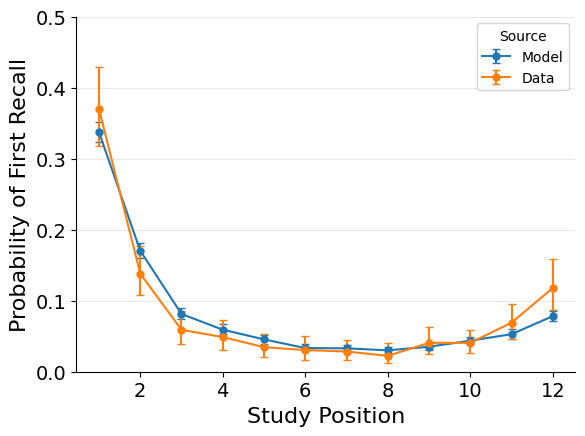

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_cat_crp.png)
plot_cat_crp


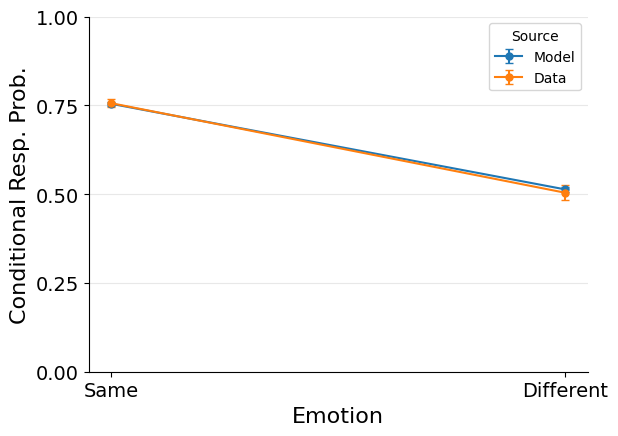

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_semantic_dist_crp.png)
plot_dist_crp


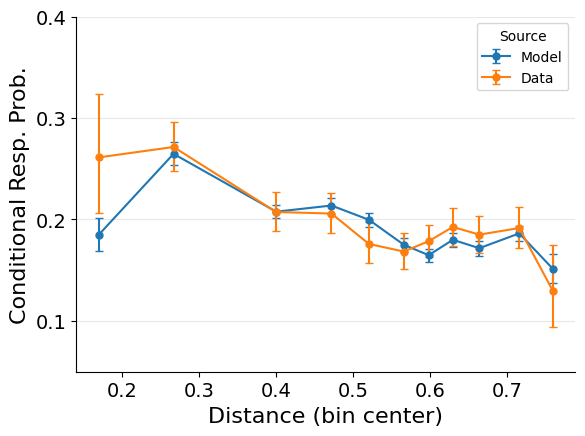

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_semantic_dist_crp_mixed.png)
plot_dist_crp


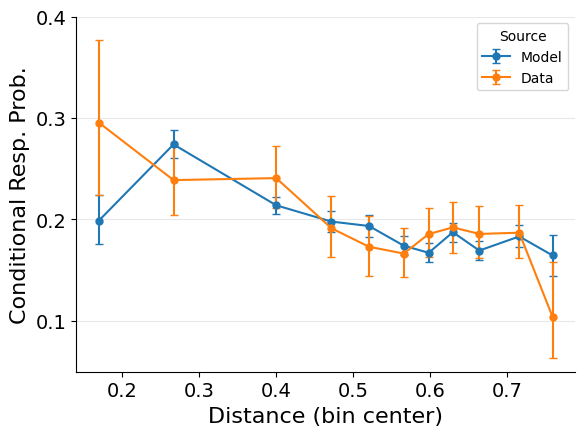

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_semantic_dist_crp_pure_emotional.png)
plot_dist_crp


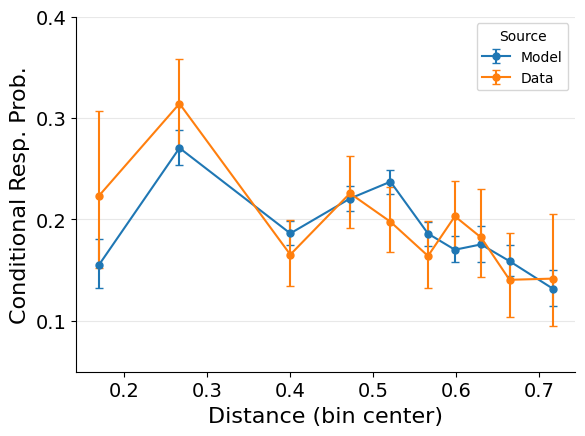

![](/Users/jordangunn/workspace/emcr3/results/figures/fitting/Dupertuys2026_eCMR_semantic_source_only_phi_learn_after_encoding_free_recall_1_semantic_learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_fixed_term_best_of_1_semantic_dist_crp_pure_neutral.png)
plot_dist_crp


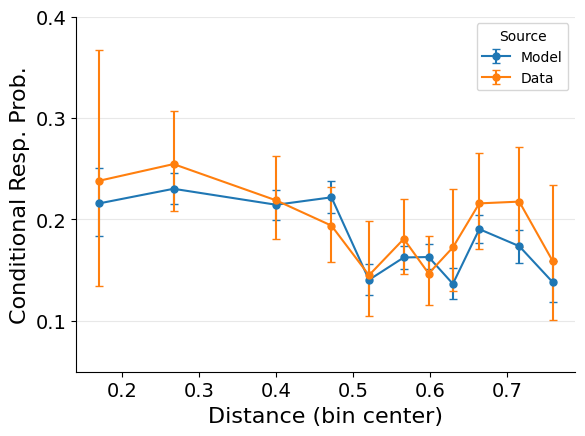

In [7]:
# code-summary: generate figures comparing model and data
for analysis_cfg in comparison_analyses:
    analysis_fn = analysis_cfg['target']
    analysis_suffix = analysis_cfg["figure_suffix"]
    figure_path = os.path.join(figure_dir, f"{figure_str}_{analysis_suffix}.png") if figure_str else None
    if figure_path:
        print(f"![]({figure_path})")

    if figure_path and os.path.exists(figure_path) and not redo_figures:
        display(Image(filename=figure_path))
        continue

    if analysis_cfg.get('color_cycle') is None:
        color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
    else:
        color_cycle = analysis_cfg['color_cycle'].copy()

    trial_mask = generate_trial_mask(data, trial_query)
    sim_trial_mask = generate_trial_mask(sim, trial_query)

    base_kwargs = {
        "datasets": [sim, data],
        "trial_masks": [np.array(sim_trial_mask), np.array(trial_mask)],
        "color_cycle": color_cycle,
        "labels": list(analysis_cfg['labels']),
        "contrast_name": analysis_cfg['contrast_name'],
        "axis": None,
    }
    base_kwargs |= analysis_cfg['kwargs']

    trial_filter_field = base_kwargs.pop("trial_filter_field", None)
    trial_filter_values = base_kwargs.pop("trial_filter_values", None)
    if trial_filter_field is not None:
        if trial_filter_values is None:
            raise ValueError("trial_filter_values must be provided when trial_filter_field is set")
        trial_filter_values = list(trial_filter_values)
        current_datasets = base_kwargs["datasets"]
        current_trial_masks = base_kwargs["trial_masks"]
        base_kwargs["trial_masks"] = [
            np.array(
                trial_mask
                & np.isin(
                    np.asarray(dataset[trial_filter_field]).flatten(),
                    np.asarray(trial_filter_values),
                )
            )
            for dataset, trial_mask in zip(current_datasets, current_trial_masks)
        ]

    signature = inspect.signature(analysis_fn)
    print(analysis_fn.__name__)
    filtered_kwargs = {
        name: value
        for name, value in base_kwargs.items()
        if name in signature.parameters
    }

    axis = analysis_fn(**filtered_kwargs)

    if analysis_cfg.get('ylim') is not None:
        for current_axis in plt.gcf().axes:
            current_axis.set_ylim(analysis_cfg['ylim'])
    if analysis_cfg.get('yticks') is not None:
        for current_axis in plt.gcf().axes:
            current_axis.set_yticks(analysis_cfg['yticks'])
    save_current_figure(figure_dir, figure_str, suffix=analysis_suffix)
